In [264]:
import numpy as np
import importlib
import pyspoc.statistics.fractal.func as ffunc
import pyspoc.statistics.fractal.fractal_gen as fgen
import matplotlib.pyplot as plt
import piecewise_regression

In [265]:
importlib.reload(ffunc)
importlib.reload(fgen)

<module 'pyspoc.statistics.fractal.fractal_gen' from 'C:\\Users\\Garry\\OneDrive - Imperial College London\\Repos\\py-spoc\\pyspoc\\statistics\\fractal\\fractal_gen.py'>

In [266]:
from piecewise_regression import Fit
from typing import Optional

def compute_adj_r2(log_boxes: np.ndarray, piecewise_fit: Fit) -> float:
    results = piecewise_fit.get_results()
    n = log_boxes.shape[0]
    p = piecewise_fit.n_breakpoints * 2
    tss = log_boxes.var() * log_boxes.shape[0]
    rss = results["rss"]
    r_sq = 1 - rss / tss
    adj_r_sq = 1 - (n - 1) / (n - 1 - p) * (1 - r_sq)
    return adj_r_sq

def get_best_parsimonous_model_fit(neg_log_scales: np.ndarray, 
                                   log_boxes: np.ndarray, 
                                   adj_r2_tol: float = 0.02) -> Optional[Fit]:
    
    max_breakpoints = int(neg_log_scales.shape[0] / 4)
    prev_adj_r2 = 10 ** -5

    for n_breakpoints in range(1, max_breakpoints + 1):
        pw_fit = piecewise_regression.Fit(neg_log_scales, log_boxes, n_breakpoints=n_breakpoints)
        results = pw_fit.get_results()

        if not results["converged"]:
            break # Terminate on non-convergence.

        adj_r2 = compute_adj_r2(log_boxes, pw_fit)
        pct_improvement = (adj_r2 - prev_adj_r2) / (prev_adj_r2)
        # print(adj_r2, prev_adj_r2, pct_improvement)

        if pct_improvement < adj_r2_tol:
            break
            
        prev_adj_r2 = adj_r2
        best_fit = pw_fit

    return best_fit

def trim_elbows(neg_log_scales: np.ndarray, best_fit: Fit, elbow_tol: float = 0.1):
    n_breakpoints = best_fit.n_breakpoints
    fit_params = best_fit.get_params()
    alphas = []
    breakpoints = [neg_log_scales[0]]
    inner_denominator = n_breakpoints - 1
    inner_avg = 0
    outer_avg = 0

    for i in range(n_breakpoints + 1):
        j = i + 1
        alpha_key = f"alpha{j}"
        breakpoint_key = f"breakpoint{j}"
        alpha = fit_params[alpha_key]
        alphas.append(alpha)
        breakpoint = fit_params.get(breakpoint_key)

        if breakpoint:
            breakpoints.append(breakpoint)

        if i > 0 or i < n_breakpoints:
            inner_avg += alpha / inner_denominator

    # Remove left elbow if below tolerance
    if alphas[0] < inner_avg * elbow_tol:
        alphas.pop(0)
        breakpoints.pop(0)

    # Remove right elbow if below tolerance
    if alphas[-1] < inner_avg * elbow_tol:
        alphas.pop()

    tot_weight = breakpoints[-1] - breakpoints[0]
    fd = 0

    for i, alpha in enumerate(alphas):
        fd += alpha * (breakpoints[i+1] - breakpoints[i]) / tot_weight

    return fd

def compute_fd(data: np.ndarray, adj_r2_tol: float = 0.02, elbow_tol: float = 0.1):
    scales = ffunc.get_default_init_scale(data)
    boxes = ffunc._get_boxes(data, scales)
    neg_log_scales = -np.log(scales)
    log_boxes = np.log(boxes)
    best_fit = get_best_parsimonous_model_fit(neg_log_scales, log_boxes, adj_r2_tol=adj_r2_tol)    
    return trim_elbows(neg_log_scales, best_fit, elbow_tol=elbow_tol)

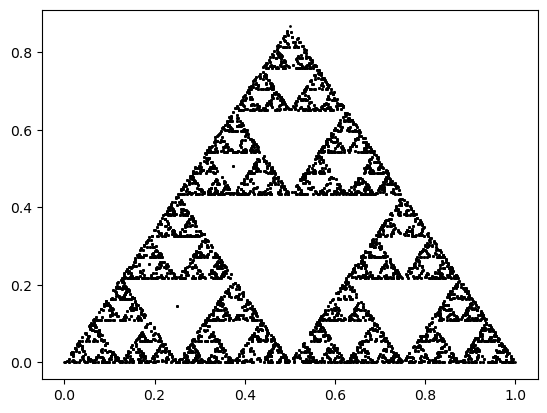

In [267]:
data = fgen.sierpinski(iters=5000)
plt.plot(*data.T, 'o', color="black", ms=1)

In [268]:
compute_fd(data)

1.515613398576389

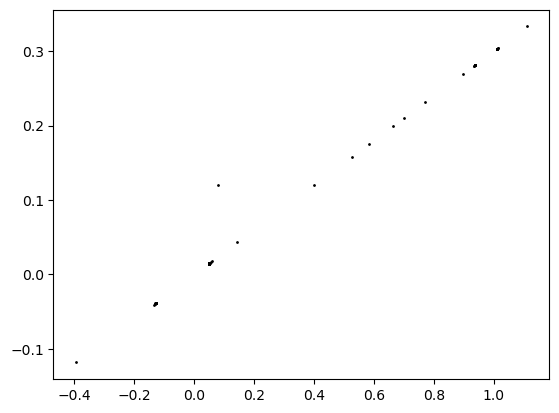

In [277]:
data = fgen.henon(iters=5000, x_start=0.08, y_start=0.12, a=1.4, b=0.3)
plt.plot(*data.T, "o", color="black", ms=1)

In [3]:
method_params = {
    "original" : [dict()],    
    "exact": [dict()],
    "generalized": [{"q" : 1}, {"q" : 2}, {"q": 3}]
}

In [4]:
datasets = {
    "norm-0-1-100000-10" : np.random.normal(size=(100000,10)),
    "norm-0-10-1000-5" : np.random.normal(scale=10, size=(1000,5)),
    "norm-5-1-100-100" : np.random.normal(loc=5, size=(100,100)),
    "norm-5-10-50-1000" : np.random.normal(loc=5, scale=10, size=(50,1000))
}

for scheme, data in datasets.items():
    for method, params_list in method_params.items():
        for params in params_list:
            box_count = BoxCountingDimension(method=method, **params)
            fd = box_count.compute(data)
            print(f"Scheme: {scheme}, Method: {method}, Params: {params}, Fractal Dimension: {fd}.")

0.011620803190602944
[0.19509051 0.18417732 0.1738746  0.16414821 0.1549659  0.14629724
 0.1381135  0.13038756 0.12309379 0.11620803 0.10970746 0.10357052
 0.09777687 0.09230732 0.08714373 0.08226899 0.07766693 0.07332231
 0.06922073 0.06534858 0.06169304 0.05824198 0.05498398 0.05190822
 0.04900452 0.04626325 0.04367533 0.04123217 0.03892567 0.03674821
 0.03469254 0.03275187 0.03091976 0.02919014 0.02755727 0.02601574
 0.02456044 0.02318655 0.02188952 0.02066504 0.01950905 0.01841773
 0.01738746 0.01641482 0.01549659 0.01462972 0.01381135 0.01303876
 0.01230938 0.0116208  0.01097075 0.01035705 0.00977769 0.00923073
 0.00871437 0.0082269  0.00776669 0.00733223 0.00692207 0.00653486
 0.0061693  0.0058242  0.0054984  0.00519082 0.00490045 0.00462633
 0.00436753 0.00412322 0.00389257 0.00367482 0.00346925 0.00327519
 0.00309198 0.00291901 0.00275573 0.00260157 0.00245604 0.00231866
 0.00218895 0.0020665  0.00195091 0.00184177 0.00173875 0.00164148
 0.00154966]
Scheme: norm-0-1-100000-10, 

In [5]:
import pyspoc.statistics.fractal.func as ffunc

In [10]:
data = datasets["norm-0-1-100000-10"]

In [12]:
elbow = ffunc.find_elbow_scale(data, return_boxes=True)

In [13]:
scale = elbow["scale"]
boxes = elbow["boxes"]

In [28]:
boxes[:,0] < scale

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [39]:
idx = np.min(np.nonzero(boxes[:,0] < scale)) - 1
print(scale, boxes[:,0][idx])

0.011620803190602944 0.011620803190602944


In [40]:
box_count = BoxCountingDimension(method="oversample")
box_count.compute(data)

KeyboardInterrupt: 

In [6]:
data = np.random.beta(1,1,size=(1000,5))
box_count = BoxCountingDimension()
box_count.compute(data)

array(1.13309503)

In [5]:
data = np.random.poisson(lam=5,size=(100000,10))
box_count = BoxCountingDimension()
box_count.compute(data)

array(1.65366852)